# Protocol

1. load PfPR data (world_pfpr.tif)
2. right click on layer and open tab symbology
3. for red band select band 1 from the dropdown
4. for green band select LCI (lower 95% CI)
5. for blue band select UCI (upper 95% CI)
6. load total 0 year old data (global_t_00_2025_CN_1km_R2025A_UA_v1.tiff)
7. load total 1-4 year old data (global_t_01_2025_CN_1km_R2025A_UA_v1.tiff)
8. load total 5-9 year old data (global_t_05_2025_CN_1km_R2025A_UA_v1.tiff)
9. Open Raster -> raster calculator
10. Output layer = pr_mean_00, Expression = ("global_t_00_2025_CN_1km_R2025A_UA_v1@1" = "global_t_00_2025_CN_1km_R2025A_UA_v1@1") * "world_pfpr@1"
11. Repeat for global_t_01_2025_CN_1km_R2025A_UA_v1.tiff
12. Output layer = pr_mean_01, Expression = ("global_t_01_2025_CN_1km_R2025A_UA_v1@1" = "global_t_01_2025_CN_1km_R2025A_UA_v1@1") * "world_pfpr@1"
13. Repeat for global_t_05_2025_CN_1km_R2025A_UA_v1.tiff
14. Output layer = pr_mean_05, Expression = ("global_t_05_2025_CN_1km_R2025A_UA_v1@1" = "global_t_05_2025_CN_1km_R2025A_UA_v1@1") * "world_pfpr@1"


In [1]:
from geotiff import GeoTiff
import numpy as np
import matplotlib.pyplot as plt
import pickle

Read in the geotiff files created from QGIS

**PfPR**:
- Age categories: 0, 1-4, 5-9, 0-9 (total)
- Geographical categories: Global (world), Africa
- PfPR categories: mean (lower and upper 95% CI also available)

**Global number of children**:
- Age categories: 0, 1-4, 5-9, 0-9

In [ ]:
pr_mean_00_world_tif = GeoTiff('pr_mean_00.tif', crs_code=4326)
pr_mean_01_world_tif = GeoTiff('pr_mean_01.tif', crs_code=4326)
pr_mean_05_world_tif = GeoTiff('pr_mean_05.tif', crs_code=4326)
pr_mean_total_world_tif = GeoTiff('pr_mean_total_world.tif', crs_code=4326)

pr_mean_00_africa_tif = GeoTiff('pr_mean_00_africa.tif', crs_code=4326)
pr_mean_01_africa_tif = GeoTiff('pr_mean_01_africa.tif', crs_code=4326)
pr_mean_05_africa_tif = GeoTiff('pr_mean_05_africa.tif', crs_code=4326)
pr_mean_total_africa_tif = GeoTiff('pr_mean_total_africa.tif', crs_code=4326)

t_00_tif = GeoTiff('global_t_00_2025_CN_1km_R2025A_UA_v1.tif')
t_01_tif = GeoTiff('global_t_01_2025_CN_1km_R2025A_UA_v1.tif')
t_05_tif = GeoTiff('global_t_05_2025_CN_1km_R2025A_UA_v1.tif')
t_total_tif = GeoTiff('global_t_0_10.tif', crs_code=4326)

<tifffile.TiffPage 0 @2986122760> parsing GDAL_NODATA tag raised ValueError('-3.4028234663852886e+38 is not castable to float32')


<tifffile.TiffPage 0 @2986122760> parsing GDAL_NODATA tag raised ValueError('-3.4028234663852886e+38 is not castable to float32')
<tifffile.TiffPage 0 @2986122760> parsing GDAL_NODATA tag raised ValueError('-3.4028234663852886e+38 is not castable to float32')
<tifffile.TiffPage 0 @2986122760> parsing GDAL_NODATA tag raised ValueError('-3.4028234663852886e+38 is not castable to float32')
<tifffile.TiffPage 0 @2986122760> parsing GDAL_NODATA tag raised ValueError('-3.4028234663852886e+38 is not castable to float32')
<tifffile.TiffPage 0 @2986122760> parsing GDAL_NODATA tag raised ValueError('-3.4028234663852886e+38 is not castable to float32')
<tifffile.TiffPage 0 @2986122760> parsing GDAL_NODATA tag raised ValueError('-3.4028234663852886e+38 is not castable to float32')
<tifffile.TiffPage 0 @2986122760> parsing GDAL_NODATA tag raised ValueError('-3.4028234663852886e+38 is not castable to float32')
<tifffile.TiffPage 0 @2986122760> parsing GDAL_NODATA tag raised ValueError('-3.4028234663

Read the geotiff data into zarr arrays

In [ ]:
pr_mean_00_world_za = pr_mean_00_world_tif.read()
pr_mean_01_world_za = pr_mean_01_world_tif.read()
pr_mean_05_world_za = pr_mean_05_world_tif.read()
pr_mean_total_world_za = pr_mean_total_world_tif.read()

pr_mean_00_africa_za = pr_mean_00_africa_tif.read()
pr_mean_01_africa_za = pr_mean_01_africa_tif.read()
pr_mean_05_africa_za = pr_mean_05_africa_tif.read()
pr_mean_total_africa_za = pr_mean_total_africa_tif.read()

t_00_za = t_00_tif.read()
t_01_za = t_01_tif.read()
t_05_za = t_05_tif.read()
t_total_za = t_total_tif.read()

Create mask arrays for PfPR greater than 0.1%

In [4]:
threshold = 0.001

# sel_mean_00_world = pr_mean_00_world_za[:] > threshold
# sel_mean_01_world = pr_mean_01_world_za[:] > threshold
# sel_mean_05_world = pr_mean_05_world_za[:] > threshold
sel_mean_total_world = pr_mean_total_world_za[:] > threshold

sel_mean_00_africa = pr_mean_00_africa_za[:] > threshold
sel_mean_01_africa = pr_mean_01_africa_za[:] > threshold
sel_mean_05_africa = pr_mean_05_africa_za[:] > threshold
sel_mean_total_africa = pr_mean_total_africa_za[:] > threshold

# sel_mean_00_africa = pr_mean_00_africa_za[:] > threshold
# sel_mean_01 = pr_mean_01_za[:] > threshold
# sel_mean_05 = pr_mean_05_za[:] > threshold

Select data using the mask arrays. The same mask is used for PfPR and number of children.


In [5]:
# pr_mean_00_world = pr_mean_00_world_za.get_mask_selection(sel_mean_00_world)
# pr_mean_01_world = pr_mean_01_world_za.get_mask_selection(sel_mean_01_world)
# pr_mean_05_world = pr_mean_05_world_za.get_mask_selection(sel_mean_05_world)
pr_mean_total_world = pr_mean_00_world_za.get_mask_selection(sel_mean_total_world)

pr_mean_00_africa = pr_mean_00_africa_za.get_mask_selection(sel_mean_00_africa)
pr_mean_01_africa = pr_mean_01_africa_za.get_mask_selection(sel_mean_01_africa)
pr_mean_05_africa = pr_mean_05_africa_za.get_mask_selection(sel_mean_05_africa)
pr_mean_total_africa = pr_mean_00_africa_za.get_mask_selection(sel_mean_total_africa)

# t_00_world = t_00_za.get_mask_selection(sel_mean_00_world)
# t_01_world = t_01_za.get_mask_selection(sel_mean_01_world)
# t_05_world = t_05_za.get_mask_selection(sel_mean_05_world)
t_total_world = t_total_za.get_mask_selection(sel_mean_total_world)

t_00_africa = t_00_za.get_mask_selection(sel_mean_00_africa)
t_01_africa = t_01_za.get_mask_selection(sel_mean_01_africa)
t_05_africa = t_05_za.get_mask_selection(sel_mean_05_africa)
t_total_africa = t_total_za.get_mask_selection(sel_mean_total_africa)

Scale PfPR by nbins and convert to integer. This gives the bin of each pixel into which we place the number of children in that pixel

In [11]:
nbins = 200
pr_mean_total_world_bin = (pr_mean_total_world * nbins).astype(int)
pr_mean_total_africa_bin = (pr_mean_total_africa * nbins).astype(int)

pr_mean_00_africa_bin = (pr_mean_00_africa * nbins).astype(int)
pr_mean_00_africa_bin = (pr_mean_00_africa * nbins).astype(int)
pr_mean_01_africa_bin = (pr_mean_01_africa * nbins).astype(int)
pr_mean_05_africa_bin = (pr_mean_05_africa * nbins).astype(int)

Count the number of children in each PfPR bin

In [ ]:
def drop_last_bin(y):
    # add value of last bin to penultimate bin and then drop it
    # which gives nbins in total
    y[-2] += y[-1]
    return y[:-1]

count_mean_total_world = np.zeros(nbins+1)
count_mean_total_africa = np.zeros(nbins+1)
count_mean_00_africa = np.zeros(nbins+1)
count_mean_01_africa = np.zeros(nbins+1)
count_mean_05_africa = np.zeros(nbins+1)

for n, b in zip(t_total_world, pr_mean_total_world_bin):
    count_mean_total_world[b] += n
for n, b in zip(t_total_africa, pr_mean_total_africa_bin):
    count_mean_total_africa[b] += n

for n, b in zip(t_00_africa, pr_mean_00_africa_bin):
    count_mean_00_africa[b] += n
for n, b in zip(t_01_africa, pr_mean_01_africa_bin):
    count_mean_01_africa[b] += n
for n, b in zip(t_05_africa, pr_mean_05_africa_bin):
    count_mean_05_africa[b] += n

count_mean_total_world = drop_last_bin(count_mean_total_world)
count_mean_total_africa = drop_last_bin(count_mean_total_africa)
count_mean_00_africa = drop_last_bin(count_mean_00_africa)
count_mean_01_africa = drop_last_bin(count_mean_01_africa)
count_mean_05_africa = drop_last_bin(count_mean_05_africa)

Pickle and save the results for further analysis

In [ ]:
a = (
    count_mean_total_world,
    count_mean_total_africa,
    count_mean_00_africa,
    count_mean_01_africa,
    count_mean_05_africa,
)
with open('../Data/Notbooks/pfpr_0-9.pickle', 'wb') as f:
    pickle.dump(a, f)

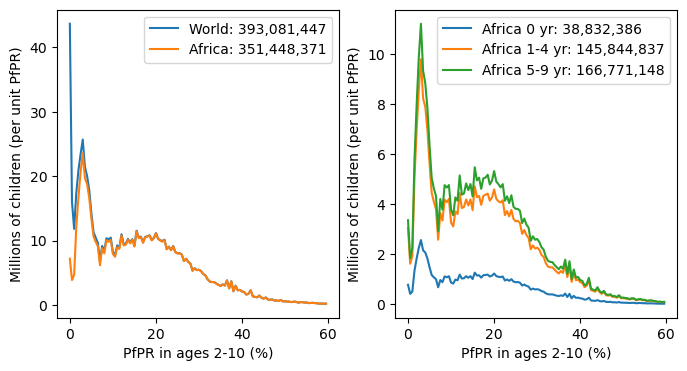

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

s = slice(0, int(60*nbins/100))

ax = axs[0]
ax.plot(np.linspace(0, 100, nbins+1)[s], count_mean_total_world[s] * nbins / 100 * 1e-6, label=f'World: {sum(count_mean_total_world):,.0f}')
ax.plot(np.linspace(0, 100, nbins+1)[s], count_mean_total_africa[s] * nbins / 100 * 1e-6, label=f'Africa: {sum(count_mean_total_africa):,.0f}')
ax.legend()
ax.set_ylabel('Millions of children (per unit PfPR)')
ax.set_xlabel('PfPR in ages 2-10 (%)')

ax = axs[1]
ax.plot(np.linspace(0, 100, nbins+1)[s], count_mean_00_africa[s] * nbins / 100 * 1e-6, label=f'Africa 0 yr: {sum(count_mean_00_africa):,.0f}')
ax.plot(np.linspace(0, 100, nbins+1)[s], count_mean_01_africa[s] * nbins / 100 * 1e-6, label=f'Africa 1-4 yr: {sum(count_mean_01_africa):,.0f}')
ax.plot(np.linspace(0, 100, nbins+1)[s], count_mean_05_africa[s] * nbins / 100 * 1e-6, label=f'Africa 5-9 yr: {sum(count_mean_05_africa):,.0f}')
ax.legend()
ax.set_ylabel('Millions of children (per unit PfPR)')
ax.set_xlabel('PfPR in ages 2-10 (%)');